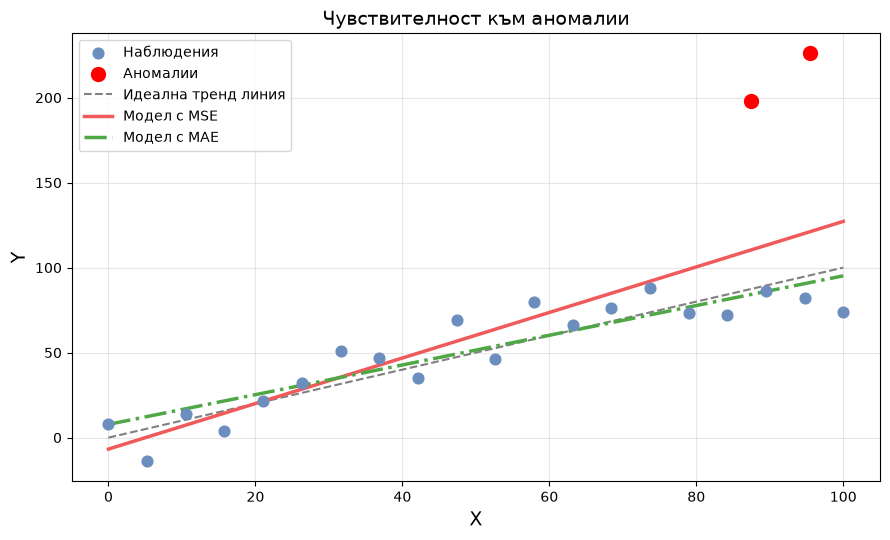

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, QuantileRegressor

# 1. Данни
np.random.seed(52)
X_normal = np.linspace(0, 100, 20).reshape(-1, 1)
# Идеална права: y = 1.0 * x
y_ideal = 1.0 * X_normal.ravel()
# Добавяне на шум за нормалните наблюдения
y_normal = y_ideal + np.random.normal(0, 15, size=X_normal.shape[0])

# Аномалии (извънредни стойности)
X_outliers = np.array([[87.5], [95.5]])
y_outliers = np.array([198, 226])

# Комбинирани данни
X_all = np.vstack([X_normal, X_outliers])
y_all = np.concatenate([y_normal, y_outliers])

# 2. Модели
# Идеална тренд линия (y = x)
X_plot = np.linspace(0, 100, 100).reshape(-1, 1)
y_ideal_plot = 1.0 * X_plot.ravel()

# Модел с MSE (Обикновена линейна регресия OLS)
mse_model = LinearRegression()
mse_model.fit(X_all, y_all)
y_mse_pred = mse_model.predict(X_plot)

# Модел с MAE (Медианна регресия / Quantile Regression с quantile=0.5)
mae_model = QuantileRegressor(quantile=0.5, alpha=0)
mae_model.fit(X_all, y_all)
y_mae_pred = mae_model.predict(X_plot)

# 3. Визуализация
plt.figure(figsize=(9, 5.5))

# Точки
plt.scatter(X_normal, y_normal, color='#6C8EBF', s=60, label='Наблюдения', zorder=3)
plt.scatter(X_outliers, y_outliers, color='red', s=100, label='Аномалии', zorder=4)

# Линии
plt.plot(X_plot, y_ideal_plot, color='gray', linestyle='--', label='Идеална тренд линия', zorder=2)
plt.plot(X_plot, y_mse_pred, color='#F05A5B', linewidth=2.5, label='Модел с MSE', zorder=2)
plt.plot(X_plot, y_mae_pred, color='#4FA845', linewidth=2.5, linestyle='-.', label='Модел с MAE', zorder=2)

# Настройки на графиката
plt.title('Чувствителност към аномалии', fontsize=14)
plt.ylabel('Y', fontsize=14)
plt.xlabel('X', fontsize=14)
plt.grid(True, linestyle='-', alpha=0.3)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('./beamer/images/reg_metrics_sensitivity_to_outliers.png', dpi=1000)